In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Data Preparation**

In [2]:
# Load datasets
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [3]:
# Basic info about data
print("TRADES SHAPE:", trades.shape)
print("SENTIMENT SHAPE:", sentiment.shape)

print("\nTRADES COLUMNS:\n", trades.columns)
print("\nSENTIMENT HEAD:\n", sentiment.head())

TRADES SHAPE: (211224, 16)
SENTIMENT SHAPE: (2644, 4)

TRADES COLUMNS:
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

SENTIMENT HEAD:
     timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [4]:
# finding missing values
print("\nMissing values (trades):\n", trades.isnull().sum())
print("\nMissing values (sentiment):\n", sentiment.isnull().sum())


Missing values (trades):
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values (sentiment):
 timestamp         0
value             0
classification    0
date              0
dtype: int64


In [5]:
# finding duplicates
print("\nDuplicate rows (trades):", trades.duplicated().sum())
print("Duplicate rows (sentiment):", sentiment.duplicated().sum())


Duplicate rows (trades): 0
Duplicate rows (sentiment): 0


In [6]:
# convert trader timestamps
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

# extracting date 
trades['date'] = trades['Timestamp IST'].dt.date

# convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [24]:
# Behavior = ALL trades (activity, risk, bias)
behavior = trades.copy()

behavior_features = behavior.groupby(['Account', 'date']).agg(
    
    # Total trades per day
    trade_count=('Order ID', 'count'),
    
    # Total capital used
    total_volume=('Size USD', 'sum'),
    
    # Average trade size (risk proxy)
    avg_trade_size=('Size USD', 'mean'),
    
    # Directional counts
    buy_count=('Side',lambda x: (x == 'BUY').sum()),
    sell_count=('Side',lambda x: (x == 'SELL').sum())

).reset_index()

# Long ratio = % BUY trades
behavior_features['long_ratio'] = (
    behavior_features['buy_count'] / behavior_features['trade_count']
)

In [25]:
# Performance = ONLY trades where PnL is realized
performance = trades[trades['Closed PnL'] != 0].copy()

performance_features = performance.groupby(['Account', 'date']).agg(
    
    # Total profit/loss per day
    total_pnl=('Closed PnL', 'sum'),
    
    # Number of completed trades
    trades_closed=('Closed PnL', 'count'),
    
    # Winning trades
    wins=('Closed PnL',lambda x: (x > 0).sum()),
    
    # Loss-making trades
    losses=('Closed PnL',lambda x: (x < 0).sum())

).reset_index()

# Win rate calculation
performance_features['win_rate'] = (
    performance_features['wins'] / performance_features['trades_closed']
)

In [26]:
# Merge behavior + performance
df = pd.merge(
    behavior_features,
    performance_features,
    on=['Account', 'date'],
    how='left'
)
# Merge sentiment
df = pd.merge(
    df,
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)
# Rename for clarity
df.rename(columns={'classification': 'sentiment'}, inplace=True)

**analysis/plots**

In [10]:
# Behavior vs sentiment
behavior_summary = df.groupby('sentiment').agg(
    avg_trades=('trade_count', 'mean'),
    avg_size=('avg_trade_size', 'mean'),
    avg_long_ratio=('long_ratio', 'mean')
)

print(behavior_summary)

               avg_trades     avg_size  avg_long_ratio
sentiment                                             
Extreme Fear   133.750000  6773.464125        0.531533
Extreme Greed   76.030418  5371.637182        0.473116
Fear            98.153968  8975.928546        0.518967
Greed           77.628086  6427.866594        0.471594
Neutral        100.228723  6963.694861        0.472431


In [11]:
# Performance vs sentiment
performance_summary = df.groupby('sentiment').agg(
    avg_pnl=('total_pnl', 'mean'),
    median_pnl=('total_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean')
)

print(performance_summary)

                   avg_pnl   median_pnl  avg_win_rate
sentiment                                            
Extreme Fear   5819.765736   632.303024      0.771535
Extreme Greed  6856.493209  1053.349222      0.867883
Fear           7544.169532   669.381363      0.862488
Greed          4799.395699   803.968004      0.846074
Neutral        4684.495201   567.796382      0.835721


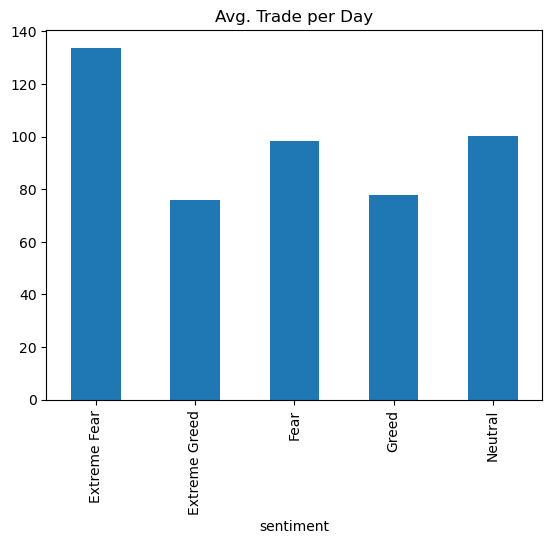

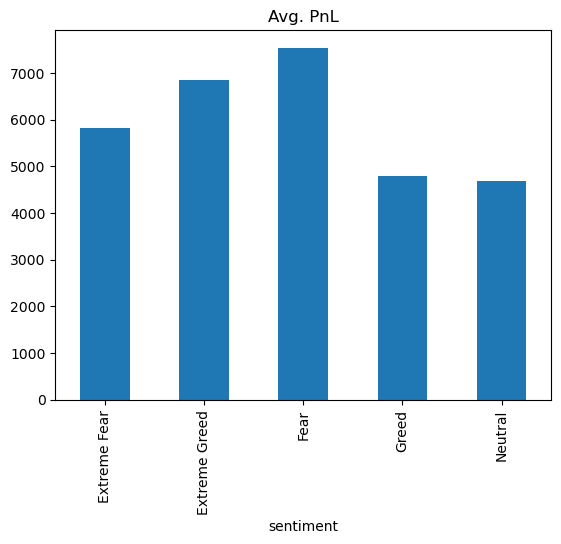

In [23]:
# Avg trades per sentiment
df.groupby('sentiment')['trade_count'].mean().plot(kind='bar')
plt.title("Avg. Trade per Day")
plt.show()

# Avg PnL
df.groupby('sentiment')['total_pnl'].mean().plot(kind='bar')
plt.title("Avg. PnL")
plt.show()

In [13]:
# Market segmentation

In [14]:
# Risk
df['risk_level'] = pd.qcut(
    df['avg_trade_size'],
    3,
    labels=['Low', 'Medium', 'High']
)
# Activity
df['activity_level'] = pd.qcut(
    df['trade_count'],
    3,
    labels=['Low', 'Medium', 'High']
)

In [15]:
# Segment analysis
segment_analysis = df.groupby(['risk_level', 'sentiment']).agg(
    avg_pnl=('total_pnl', 'mean'),
    avg_win_rate=('win_rate', 'mean')
).reset_index()

print(segment_analysis)


   risk_level      sentiment       avg_pnl  avg_win_rate
0         Low   Extreme Fear   -790.256479      0.645766
1         Low  Extreme Greed   2197.628617      0.871047
2         Low           Fear    569.744093      0.850972
3         Low          Greed    680.224634      0.838592
4         Low        Neutral    132.387390      0.818632
5      Medium   Extreme Fear   3827.774265      0.814726
6      Medium  Extreme Greed  12517.724485      0.866148
7      Medium           Fear   7576.379673      0.893251
8      Medium          Greed   5474.810356      0.872358
9      Medium        Neutral   8579.915409      0.842161
10       High   Extreme Fear  13250.819558      0.824461
11       High  Extreme Greed   6477.778711      0.865874
12       High           Fear  15212.785068      0.837050
13       High          Greed   8148.309955      0.832018
14       High        Neutral   4852.347862      0.845455


C:\Users\user\AppData\Local\Temp\ipykernel_14532\700292091.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = df.groupby(['risk_level', 'sentiment']).agg(


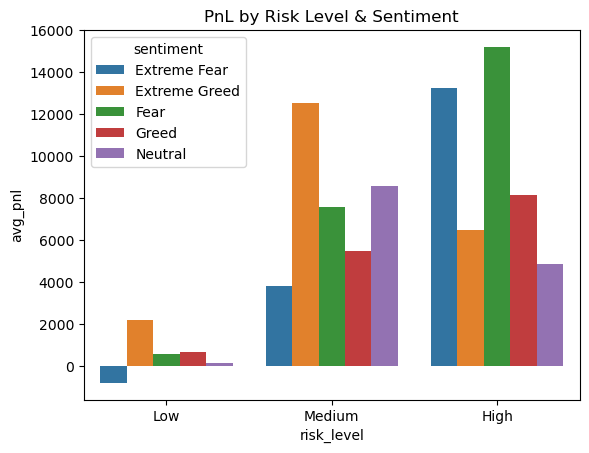

In [17]:
sns.barplot(data=segment_analysis, x='risk_level', y='avg_pnl', hue='sentiment')
plt.title("PnL by Risk Level & Sentiment")
plt.show()